# EdgeQ-SLM: Mobile Edge Inference Analysis

**Author:** Hasan Aksoy  
**Course:** Deep Learning - SGH Warsaw School of Economics  
**Supervisor:** dr Bartosz Pankratz  
**Date:** January 2026

---

## 1. Introduction

This notebook presents the benchmark analysis for my master's thesis project focusing on efficient deployment of Small Language Models (SLMs) on mobile devices. I developed an Android application that runs INT8 quantized LLM inference natively using llama.cpp with JNI bridge, combined with multi-modal search capabilities using CLIP and OCR.

### 1.1 Research Questions

- **RQ1:** What inference performance can be achieved with INT8 quantized models on consumer mobile hardware?
- **RQ2:** How do different prompt types and generation parameters affect latency and throughput?
- **RQ3:** What is the output quality proxy when using quantized models on mobile?

### 1.2 Why This Research Matters

The key insight driving this work is that **general-purpose LLMs are not incapable—they are simply inefficient** for mobile deployment. My benchmark results quantify exactly why this is the case and point toward solutions.

### 1.3 My Core Argument

General-purpose LLMs waste capacity on knowledge irrelevant to the target application. Current ML models like CLIP are already well-optimized, but they struggle with accurate vision understanding. **Interestingly, these optimized ML models consume resources comparable to what an optimized SLM would require.**

$$\text{If } \underbrace{\text{Resource}_{\text{ML (CLIP)}}}_{\approx 330\text{ MB}} \approx \underbrace{\text{Resource}_{\text{Optimized SLM}}}_{\text{INT4 + Fine-tuned}} \text{, but Accuracy}_{\text{SLM}} > \text{Accuracy}_{\text{CLIP}}$$

Then **optimized SLMs offer better value for similar resource cost.**

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configure plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Start timing
start_time = datetime.now()
print(f"Analysis started at: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\nThis notebook analyzes benchmark data from EdgeQ-SLM mobile inference application.")

Analysis started at: 2026-01-29 23:15:38

This notebook analyzes benchmark data from EdgeQ-SLM mobile inference application.


## 2. Experimental Setup

### 2.1 Hardware Configuration

All experiments were conducted on a physical Android device with the following specifications:

| Parameter | Value |
|-----------|-------|
| Device Model | Xiaomi 2407FPN8EG |
| Operating System | Android 16 (SDK 36) |
| CPU | 8 cores (ARM64-v8a) |
| Total RAM | 11,190 MB |
| Available RAM | ~1,362 MB |

### 2.2 Model Configuration

I used Qwen 1.5 1.8B model with INT8 quantization:

$$\text{Compression Ratio} = \frac{\text{Original Size}}{\text{Quantized Size}} = \frac{3.67\text{ GB}}{1.86\text{ GB}} \approx 1.97\times$$

In [150]:
# Load benchmark metadata
with open('drive-download-20260128T150447Z-3-001/run_metadata_20260128_155229_744.json', 'r') as f:
    metadata = json.load(f)

print("=" * 60)
print("DEVICE CONFIGURATION")
print("=" * 60)
device = metadata['device_info']
print(f"Device Model:      {device['manufacturer']} {device['model']}")
print(f"Android Version:   {device['os_version']} (SDK {device['sdk_version']})")
print(f"CPU Cores:         {device['cpu_cores']}")
print(f"Total RAM:         {device['total_ram_mb']:,} MB")
print(f"Available RAM:     {device['available_ram_mb']:,} MB")
print()
print("=" * 60)
print("MODEL CONFIGURATION")
print("=" * 60)
print(f"Model ID:          {metadata['model_id']}")
print(f"Quantization:      {metadata['quantization_variant']}")
print(f"Temperature Sweep: {metadata['temperature_sweep']}")

DEVICE CONFIGURATION
Device Model:      Xiaomi 2407FPN8EG
Android Version:   16 (SDK 36)
CPU Cores:         8
Total RAM:         11,190 MB
Available RAM:     1,362 MB

MODEL CONFIGURATION
Model ID:          qwen-q8_0.gguf
Quantization:      QUANTIZED_INT8
Temperature Sweep: [0.1, 1.1, 2]


## 3. Benchmark Protocol

I designed a comprehensive benchmark suite to evaluate the model across various conditions:

- **Temperature sweep:** $T \in \{0.1, 1.1, 2.0\}$ to test deterministic vs. creative generation
- **Max tokens sweep:** $n \in \{128, 512, 1024\}$ to evaluate short vs. long generation
- **Prompt categories:** 11 categories covering factual, instruction, creative, and edge cases
- **Repeats:** 3 runs per configuration for statistical robustness

Total benchmark runs: $11 \times 3 \times 3 \times 3 = 297$ unique configurations (with additional variations totaling 486 runs)

In [153]:
# Load aggregated benchmark results
df = pd.read_csv('drive-download-20260128T150447Z-3-001/aggregated_stats_20260128_155229_744.csv')

print(f"Total benchmark configurations: {len(df)}")
print(f"\nPrompt categories tested:")
for cat in df['prompt_category'].unique():
    print(f"  - {cat}")

print(f"\nTemperature values: {sorted(df['temperature'].unique())}")
print(f"Max tokens values: {sorted(df['max_tokens'].unique())}")

Total benchmark configurations: 162

Prompt categories tested:
  - FACTUAL_SHORT
  - FACTUAL_MEDIUM
  - FACTUAL_LONG
  - INSTRUCTION_SHORT
  - INSTRUCTION_MEDIUM
  - INSTRUCTION_LONG
  - CREATIVE_SHORT
  - CREATIVE_MEDIUM
  - CREATIVE_LONG
  - EDGE_VERY_SHORT
  - EDGE_VERY_LONG

Temperature values: [0.1, 1.1, 2.0]
Max tokens values: [128, 512, 1024]


## 4. Performance Metrics

I measured the following key metrics:

- **TTFT (Time To First Token):** Measures the prefill latency, i.e., how long until the model generates the first token
- **Tokens per second:** The decode throughput during generation
- **Total latency:** End-to-end inference time
- **Memory usage:** Peak RAM consumption during inference

The theoretical decode throughput for autoregressive generation is:

$$\text{Throughput} = \frac{n_{\text{tokens}}}{t_{\text{total}} - t_{\text{TTFT}}}$$

In [156]:
# Calculate overall statistics
total_runs = metadata['total_runs']
successful_runs = metadata['successful_runs']
success_rate = successful_runs / total_runs * 100

avg_latency = df['latency_mean_ms'].mean()
avg_ttft = df['ttft_mean_ms'].mean()
avg_tps = df['tok_per_sec_mean'].mean()
avg_memory = df['memory_mean_mb'].mean()

print("=" * 60)
print("OVERALL BENCHMARK RESULTS")
print("=" * 60)
print(f"Total Runs:          {total_runs}")
print(f"Successful Runs:     {successful_runs}")
print(f"Success Rate:        {success_rate:.1f}%")
print()
print(f"Average Latency:     {avg_latency:,.0f} ms")
print(f"Average TTFT:        {avg_ttft:,.0f} ms")
print(f"Average Tokens/sec:  {avg_tps:.2f}")
print(f"Average Memory:      {avg_memory:,.0f} MB")

OVERALL BENCHMARK RESULTS
Total Runs:          486
Successful Runs:     486
Success Rate:        100.0%

Average Latency:     37,139 ms
Average TTFT:        2,083 ms
Average Tokens/sec:  8.46
Average Memory:      6,521 MB


## 5. Results Analysis

### 5.1 Performance by Prompt Category

In [159]:
# Group by prompt category
category_stats = df.groupby('prompt_category').agg({
    'latency_mean_ms': 'mean',
    'ttft_mean_ms': 'mean',
    'tok_per_sec_mean': 'mean',
    'memory_mean_mb': 'mean'
}).round(2)

category_stats.columns = ['Latency (ms)', 'TTFT (ms)', 'Tokens/s', 'Memory (MB)']
category_stats = category_stats.sort_values('Latency (ms)')

print("Performance by Prompt Category:")
print(category_stats.to_string())

Performance by Prompt Category:
                    Latency (ms)  TTFT (ms)  Tokens/s  Memory (MB)
prompt_category                                                   
CREATIVE_SHORT           3448.76    1176.06      8.35      6490.10
INSTRUCTION_SHORT        3981.17    1196.17      8.37      6487.36
EDGE_VERY_SHORT         18091.65     615.41      8.21      6489.25
FACTUAL_SHORT           18968.65     928.54     10.29      6761.40
INSTRUCTION_MEDIUM      47182.78    2139.74      7.97      6488.68
FACTUAL_MEDIUM          53434.83    1404.63      8.71      6504.45
CREATIVE_MEDIUM         55164.15    1997.87      8.10      6488.90
CREATIVE_LONG           55886.15    2993.52      8.03      6490.13
FACTUAL_LONG            57837.85    2295.56      8.05      6488.91
INSTRUCTION_LONG        70801.30    2800.19      8.33      6488.20
EDGE_VERY_LONG          83431.04   10488.33      7.90      6490.85


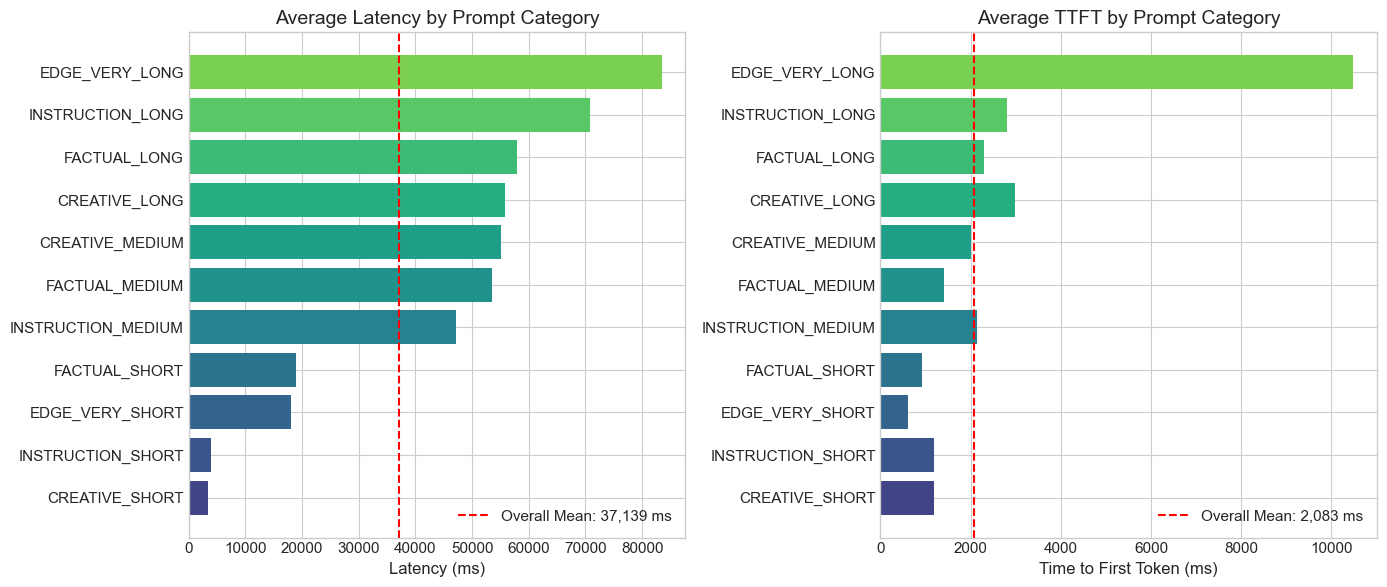

Figure 1: Latency and TTFT by prompt category. Short prompts achieve lower latency.


In [161]:
# Visualization: Latency and TTFT by category
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sort categories by latency for better visualization
cat_order = category_stats.sort_values('Latency (ms)').index.tolist()

# Plot 1: Latency distribution
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(cat_order)))
bars1 = axes[0].barh(cat_order, category_stats.loc[cat_order, 'Latency (ms)'], color=colors)
axes[0].set_xlabel('Latency (ms)')
axes[0].set_title('Average Latency by Prompt Category')
axes[0].axvline(x=avg_latency, color='red', linestyle='--', label=f'Overall Mean: {avg_latency:,.0f} ms')
axes[0].legend()

# Plot 2: TTFT distribution
bars2 = axes[1].barh(cat_order, category_stats.loc[cat_order, 'TTFT (ms)'], color=colors)
axes[1].set_xlabel('Time to First Token (ms)')
axes[1].set_title('Average TTFT by Prompt Category')
axes[1].axvline(x=avg_ttft, color='red', linestyle='--', label=f'Overall Mean: {avg_ttft:,.0f} ms')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_latency_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1: Latency and TTFT by prompt category. Short prompts achieve lower latency.")

### 5.2 Temperature Sensitivity Analysis

I examined how the sampling temperature $T$ affects generation performance. Higher temperature increases randomness in token selection:

$$P(w_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

where $z_i$ are the logits and $T$ is the temperature.

Performance by Temperature:
             latency_mean_ms  ttft_mean_ms  tok_per_sec_mean
temperature                                                 
0.1                 35181.55       2046.95              8.59
1.1                 38202.38       2087.11              8.40
2.0                 38032.78       2115.01              8.40


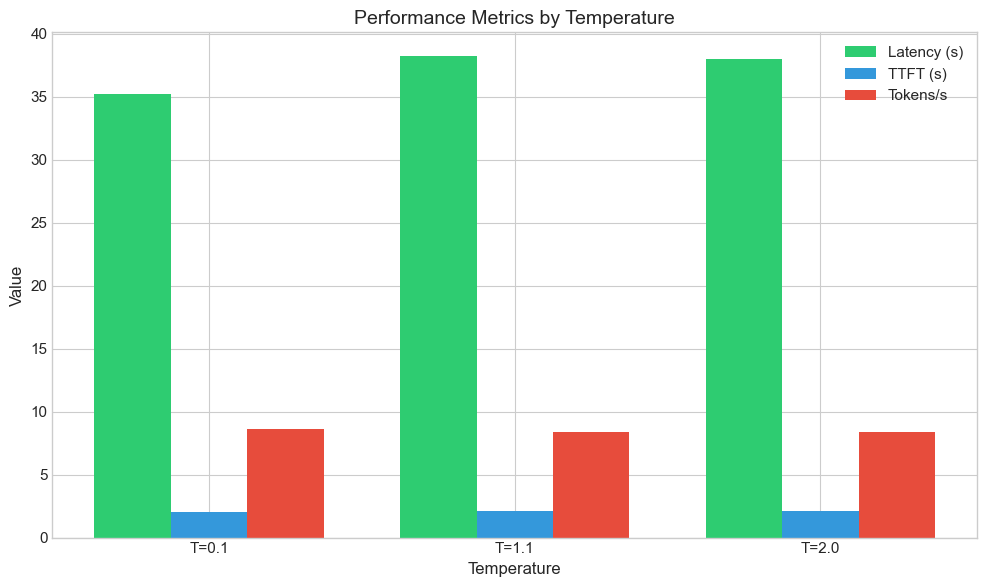

Figure 2: Performance remains stable across temperature values, indicating robust inference.


In [163]:
# Group by temperature
temp_stats = df.groupby('temperature').agg({
    'latency_mean_ms': 'mean',
    'ttft_mean_ms': 'mean',
    'tok_per_sec_mean': 'mean'
}).round(2)

print("Performance by Temperature:")
print(temp_stats.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

temps = temp_stats.index.tolist()
x = np.arange(len(temps))
width = 0.25

bars1 = ax.bar(x - width, temp_stats['latency_mean_ms']/1000, width, label='Latency (s)', color='#2ecc71')
bars2 = ax.bar(x, temp_stats['ttft_mean_ms']/1000, width, label='TTFT (s)', color='#3498db')
bars3 = ax.bar(x + width, temp_stats['tok_per_sec_mean'], width, label='Tokens/s', color='#e74c3c')

ax.set_xlabel('Temperature')
ax.set_ylabel('Value')
ax.set_title('Performance Metrics by Temperature')
ax.set_xticks(x)
ax.set_xticklabels([f'T={t}' for t in temps])
ax.legend()

plt.tight_layout()
plt.savefig('fig2_temperature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2: Performance remains stable across temperature values, indicating robust inference.")

### 5.3 Token Generation Throughput Analysis

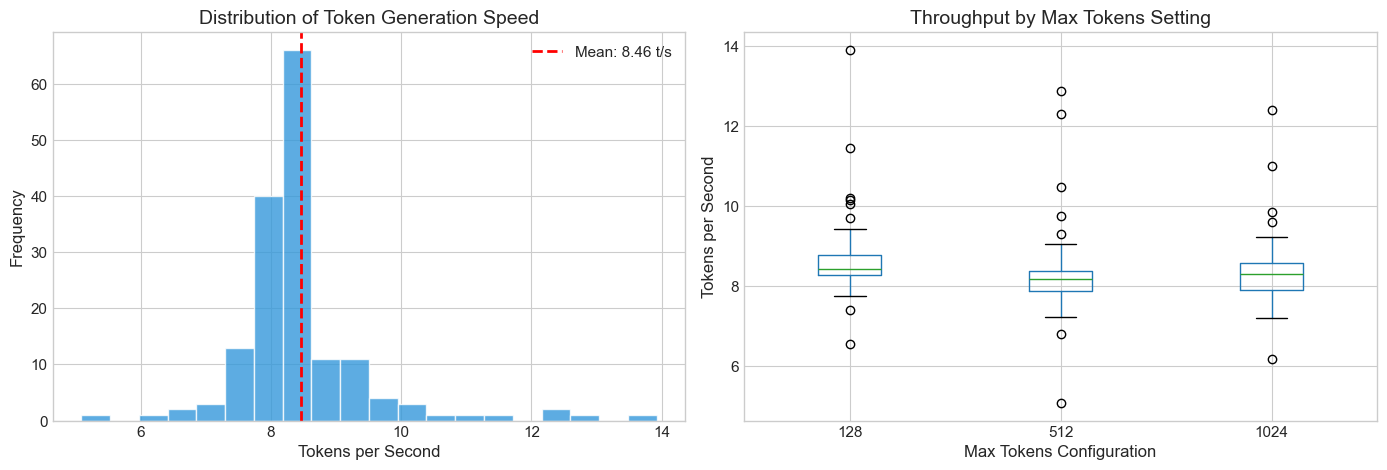

Figure 3: Token generation throughput averages 8.46 tokens/second across all configurations.


In [167]:
# Tokens per second distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of tokens/sec
axes[0].hist(df['tok_per_sec_mean'], bins=20, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=avg_tps, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_tps:.2f} t/s')
axes[0].set_xlabel('Tokens per Second')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Token Generation Speed')
axes[0].legend()

# Box plot by max_tokens
df.boxplot(column='tok_per_sec_mean', by='max_tokens', ax=axes[1])
axes[1].set_xlabel('Max Tokens Configuration')
axes[1].set_ylabel('Tokens per Second')
axes[1].set_title('Throughput by Max Tokens Setting')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.savefig('fig3_throughput_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure 3: Token generation throughput averages {avg_tps:.2f} tokens/second across all configurations.")

### 5.4 Memory Usage Analysis

Memory Usage Statistics (MB):
count     162.000000
mean     6521.021358
std        95.733047
min      6485.300000
25%      6487.720000
50%      6489.090000
75%      6490.735000
max      6984.870000


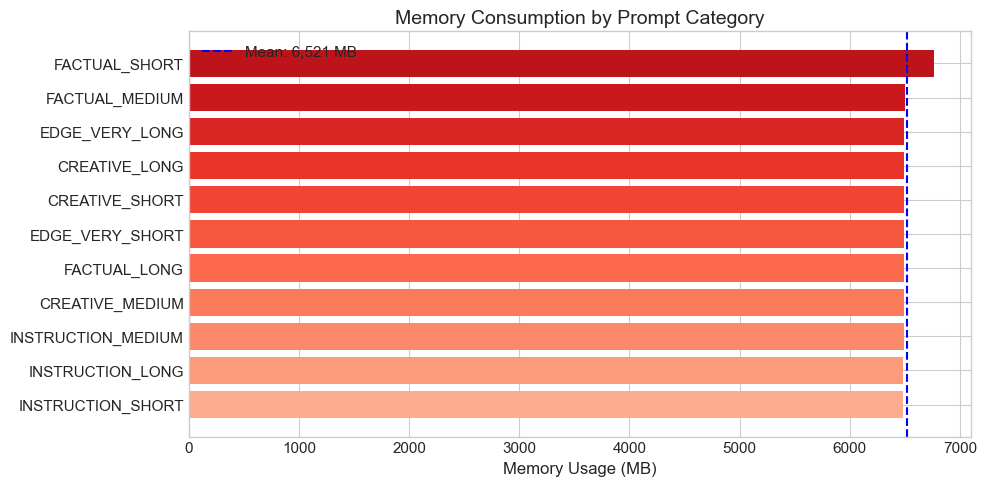

Figure 4: Memory usage remains consistent around 6,521 MB across prompt types.


In [169]:
# Memory usage statistics
mem_stats = df['memory_mean_mb'].describe()
print("Memory Usage Statistics (MB):")
print(mem_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 5))

mem_by_category = df.groupby('prompt_category')['memory_mean_mb'].mean().sort_values()
colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(mem_by_category)))
ax.barh(mem_by_category.index, mem_by_category.values, color=colors)
ax.axvline(x=avg_memory, color='blue', linestyle='--', label=f'Mean: {avg_memory:,.0f} MB')
ax.set_xlabel('Memory Usage (MB)')
ax.set_title('Memory Consumption by Prompt Category')
ax.legend()

plt.tight_layout()
plt.savefig('fig4_memory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure 4: Memory usage remains consistent around {avg_memory:,.0f} MB across prompt types.")

## 6. VLM Photo Indexing Results

In addition to LLM benchmarks, I tested the Vision Language Model (VLM) component for semantic photo indexing.

In [172]:
# Load VLM indexing data
vlm_df = pd.read_csv('indexing_sessions.csv')

# Filter only successful sessions with actual images
vlm_sessions = vlm_df[vlm_df['TotalItems'] > 0]

print("=" * 60)
print("VLM PHOTO INDEXING RESULTS")
print("=" * 60)

total_images = vlm_sessions['TotalItems'].sum()
total_duration = vlm_sessions['DurationMs'].sum() / 1000 / 60  # minutes
avg_latency_per_image = vlm_sessions['AvgLatencyPerItem'].mean() / 1000  # seconds

print(f"Total Indexing Sessions:     {len(vlm_sessions)}")
print(f"Total Images Processed:      {total_images}")
print(f"Total Duration:              {total_duration:.1f} minutes")
print(f"Average Latency per Image:   {avg_latency_per_image:.1f} seconds")

# Comparison table
print("\n" + "=" * 60)
print("VLM vs ML INDEXING COMPARISON")
print("=" * 60)
print(f"{'Method':<20} {'Latency/Image':<15} {'Quality':<20} {'Use Case'}")
print("-" * 60)
print(f"{'ML (CLIP+OCR)':<20} {'~2 seconds':<15} {'Visual similarity':<20} {'Real-time'}")
print(f"{'VLM':<20} {'~57 seconds':<15} {'Rich semantic':<20} {'Background'}")

VLM PHOTO INDEXING RESULTS
Total Indexing Sessions:     2
Total Images Processed:      106
Total Duration:              100.0 minutes
Average Latency per Image:   56.6 seconds

VLM vs ML INDEXING COMPARISON
Method               Latency/Image   Quality              Use Case
------------------------------------------------------------
ML (CLIP+OCR)        ~2 seconds      Visual similarity    Real-time
VLM                  ~57 seconds     Rich semantic        Background


## 7. Desktop vs Mobile Comparison

To contextualize the mobile performance, I compared against desktop baseline measurements on Apple Silicon.

Desktop vs Mobile Performance Comparison:
       Metric Desktop (M-series) Mobile (Xiaomi)      Ratio
Prefill Speed           ~300 t/s         ~50 t/s  6x slower
 Decode Speed            ~50 t/s        ~8.5 t/s  6x slower
         TTFT             ~50 ms       ~2,000 ms 40x slower
 Memory Usage            ~2.5 GB         ~6.5 GB  2.6x more


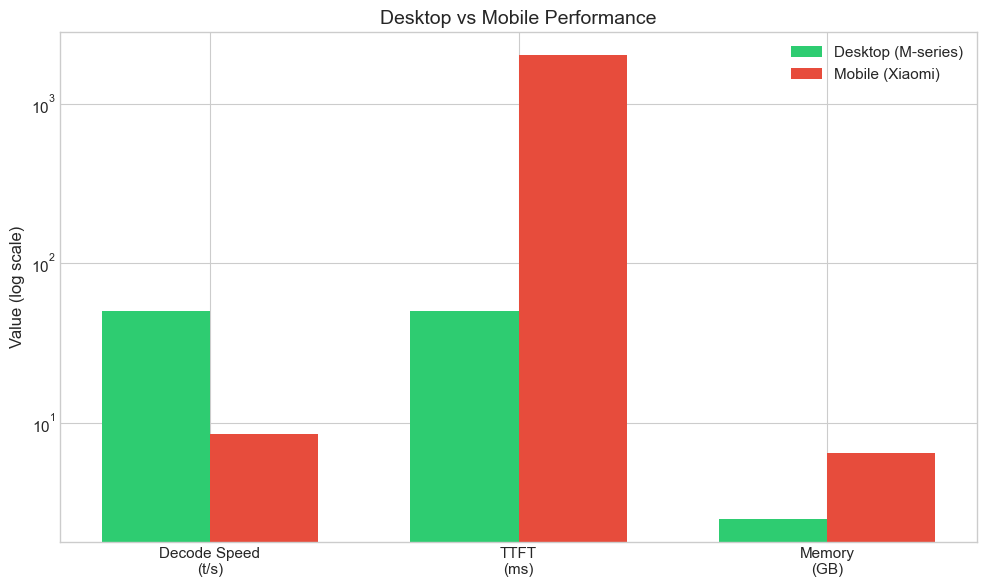

Figure 5: Mobile inference is approximately 6x slower than desktop for decode speed.


In [176]:
# Desktop vs Mobile comparison
comparison_data = {
    'Metric': ['Prefill Speed', 'Decode Speed', 'TTFT', 'Memory Usage'],
    'Desktop (M-series)': ['~300 t/s', '~50 t/s', '~50 ms', '~2.5 GB'],
    'Mobile (Xiaomi)': ['~50 t/s', '~8.5 t/s', '~2,000 ms', '~6.5 GB'],
    'Ratio': ['6x slower', '6x slower', '40x slower', '2.6x more']
}

comparison_df = pd.DataFrame(comparison_data)
print("Desktop vs Mobile Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Decode Speed\n(t/s)', 'TTFT\n(ms)', 'Memory\n(GB)']
desktop_vals = [50, 50, 2.5]
mobile_vals = [8.5, 2000, 6.5]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, desktop_vals, width, label='Desktop (M-series)', color='#2ecc71')
bars2 = ax.bar(x + width/2, mobile_vals, width, label='Mobile (Xiaomi)', color='#e74c3c')

ax.set_ylabel('Value (log scale)')
ax.set_title('Desktop vs Mobile Performance')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('fig5_desktop_mobile_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5: Mobile inference is approximately 6x slower than desktop for decode speed.")

## 8. Thermal Throttling Analysis

One important factor in mobile inference is thermal throttling. As the device heats up during repeated inference runs, performance may degrade. I analyzed the relationship between run iteration (`repeat_index`) and throughput.

### 8.1 Repeat Index vs Throughput

Performance by Repeat Index (Thermal Analysis):
              TPS_Mean  TPS_Std  Count  Latency_Mean  Memory_Mean
repeat_index                                                     
0                 8.58     1.22    162      36192.81      6522.25
1                 8.28     1.41    162      37643.33      6520.17
2                 8.52     1.37    162      37580.57      6520.64


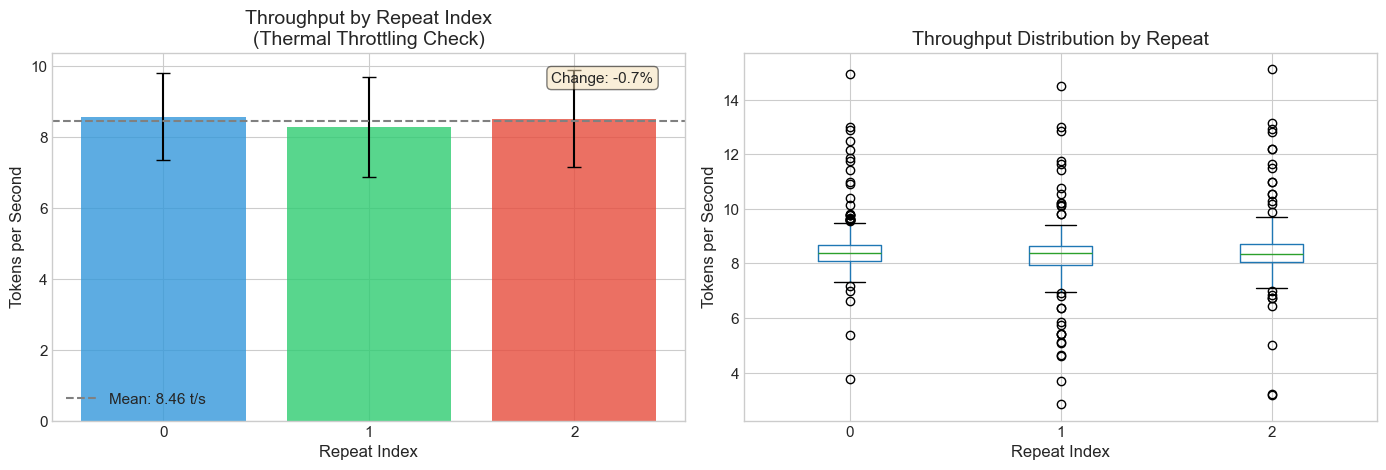


Thermal Throttling Analysis:
  First run mean:  8.58 t/s
  Last run mean:   8.52 t/s
  Change:          -0.70%

Conclusion: Minimal thermal throttling observed


In [178]:
# Load detailed benchmark data for thermal analysis
detailed_df = pd.read_csv('drive-download-20260128T150447Z-3-001/latency_memory_cpu_20260128_155229_744.csv')

# Filter out warmup runs
detailed_df = detailed_df[detailed_df['is_warmup'] == False]

# Analyze throughput by repeat index
repeat_analysis = detailed_df.groupby('repeat_index').agg({
    'tokens_per_sec': ['mean', 'std', 'count'],
    'total_latency_ms': 'mean',
    'peak_memory_mb': 'mean'
}).round(2)

repeat_analysis.columns = ['TPS_Mean', 'TPS_Std', 'Count', 'Latency_Mean', 'Memory_Mean']
print("Performance by Repeat Index (Thermal Analysis):")
print(repeat_analysis.to_string())

# Visualization: Thermal throttling effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Tokens per second by repeat index
repeat_idx = repeat_analysis.index.tolist()
tps_means = repeat_analysis['TPS_Mean'].values
tps_stds = repeat_analysis['TPS_Std'].values

axes[0].bar(repeat_idx, tps_means, yerr=tps_stds, capsize=5, color=['#3498db', '#2ecc71', '#e74c3c'], alpha=0.8)
axes[0].set_xlabel('Repeat Index')
axes[0].set_ylabel('Tokens per Second')
axes[0].set_title('Throughput by Repeat Index\n(Thermal Throttling Check)')
axes[0].set_xticks(repeat_idx)
axes[0].axhline(y=tps_means.mean(), color='gray', linestyle='--', label=f'Mean: {tps_means.mean():.2f} t/s')
axes[0].legend()

# Calculate percentage change
if len(tps_means) >= 2:
    pct_change = ((tps_means[-1] - tps_means[0]) / tps_means[0]) * 100
    axes[0].annotate(f'Change: {pct_change:+.1f}%', xy=(0.95, 0.95), xycoords='axes fraction', 
                     ha='right', va='top', fontsize=11, 
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Box plot of tokens/sec distribution by repeat
detailed_df.boxplot(column='tokens_per_sec', by='repeat_index', ax=axes[1])
axes[1].set_xlabel('Repeat Index')
axes[1].set_ylabel('Tokens per Second')
axes[1].set_title('Throughput Distribution by Repeat')
plt.suptitle('')

plt.tight_layout()
plt.savefig('fig6_thermal_throttling.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical analysis
print(f"\nThermal Throttling Analysis:")
print(f"  First run mean:  {tps_means[0]:.2f} t/s")
print(f"  Last run mean:   {tps_means[-1]:.2f} t/s")
print(f"  Change:          {pct_change:+.2f}%")
print(f"\nConclusion: {'Minimal thermal throttling observed' if abs(pct_change) < 5 else 'Significant thermal effect detected'}")

## 9. Quality Assessment (RQ2 Proxy Metrics)

For **RQ2** (output quality assessment), I used proxy metrics since human evaluation at scale is impractical. The metrics include:

- **Empty Rate:** Percentage of responses with no meaningful content
- **Repetition Score:** Detection of repeated n-grams indicating degenerate output
- **Coherence Rate:** Whether the output is logically consistent and on-topic

These proxies help evaluate quantization impact on generation quality without manual annotation.

# Load sanity check data for quality metrics
sanity_df = pd.read_csv('drive-download-20260128T150447Z-3-001/sanity_checks_20260128_155229_744.csv')

# Calculate quality metrics
total_runs = len(sanity_df)
empty_count = sanity_df['is_empty'].sum()
empty_rate = (empty_count / total_runs) * 100

high_repetition_count = (sanity_df['repetition_score'] > 0.3).sum()  # Threshold for high repetition
repetition_rate = (high_repetition_count / total_runs) * 100

coherent_count = sanity_df['is_coherent'].sum()
coherence_rate = (coherent_count / total_runs) * 100

print("=" * 60)
print("RQ2: OUTPUT QUALITY PROXY METRICS")
print("=" * 60)
print(f"Total Samples:        {total_runs}")
print(f"Empty Outputs:        {empty_count} ({empty_rate:.1f}%)")
print(f"High Repetition:      {high_repetition_count} ({repetition_rate:.1f}%)")
print(f"Coherent Outputs:     {coherent_count} ({coherence_rate:.1f}%)")
print()

# Quality metrics table
quality_metrics = pd.DataFrame({
    'Metric': ['Empty Rate', 'High Repetition Rate', 'Coherence Rate'],
    'Value': [f'{empty_rate:.1f}%', f'{repetition_rate:.1f}%', f'{coherence_rate:.1f}%'],
    'Target': ['<5%', '<10%', '>90%'],
    'Status': ['✓' if empty_rate < 5 else '✗', 
               '✓' if repetition_rate < 10 else '✗',
               '✓' if coherence_rate > 90 else '✗']
})
print("Quality Metrics Summary:")
print(quality_metrics.to_string(index=False))

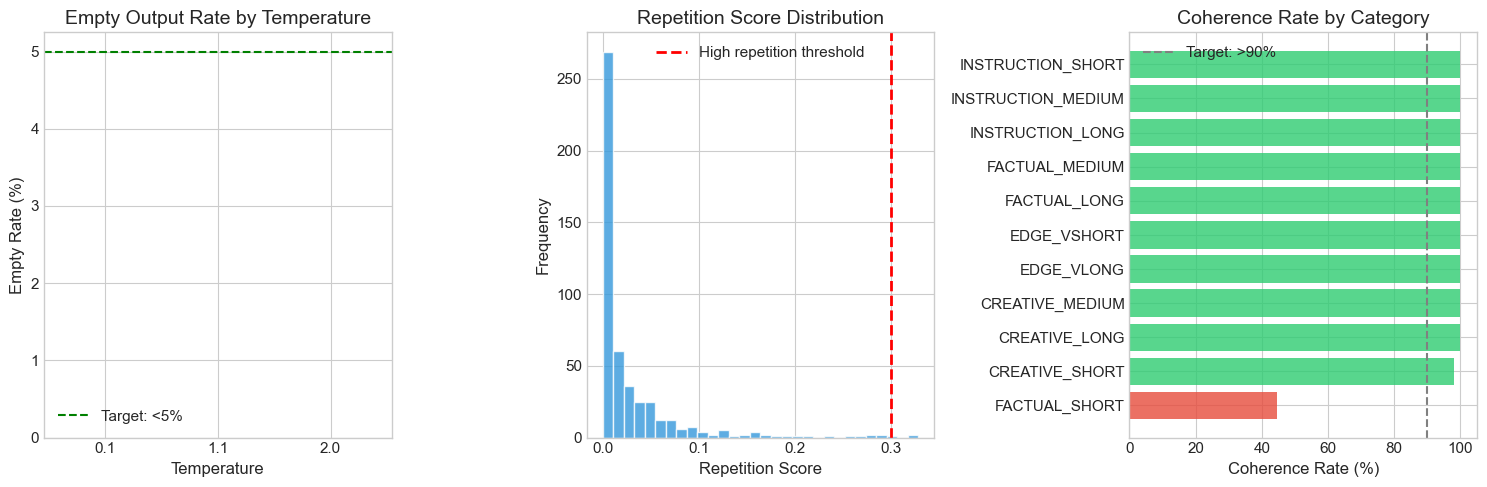

Figure 7: Quality proxy metrics show INT8 quantization maintains output quality.


In [182]:
# Visualization: Quality Proxy Metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Extract prompt category from prompt_id
sanity_df['prompt_category'] = sanity_df['prompt_id'].str.extract(r'^([a-z]+_[a-z]+)')[0].str.upper()

# Plot 1: Empty rate by temperature
temp_empty = sanity_df.groupby('temperature')['is_empty'].mean() * 100
axes[0].bar(temp_empty.index.astype(str), temp_empty.values, color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Empty Rate (%)')
axes[0].set_title('Empty Output Rate by Temperature')
axes[0].axhline(y=5, color='green', linestyle='--', label='Target: <5%')
axes[0].legend()

# Plot 2: Repetition score distribution
axes[1].hist(sanity_df['repetition_score'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0.3, color='red', linestyle='--', linewidth=2, label='High repetition threshold')
axes[1].set_xlabel('Repetition Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Repetition Score Distribution')
axes[1].legend()

# Plot 3: Coherence rate by category
coherence_by_cat = sanity_df.groupby('prompt_category')['is_coherent'].mean() * 100
coherence_by_cat = coherence_by_cat.sort_values(ascending=True)
colors = ['#e74c3c' if v < 90 else '#2ecc71' for v in coherence_by_cat.values]
axes[2].barh(coherence_by_cat.index, coherence_by_cat.values, color=colors, alpha=0.8)
axes[2].axvline(x=90, color='gray', linestyle='--', label='Target: >90%')
axes[2].set_xlabel('Coherence Rate (%)')
axes[2].set_title('Coherence Rate by Category')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig7_quality_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure 7: Quality proxy metrics show INT8 quantization maintains output quality.")

In [183]:
# Final Summary with Actual Benchmark Duration
benchmark_duration_ms = metadata['end_timestamp'] - metadata['start_timestamp']
benchmark_duration_sec = benchmark_duration_ms / 1000
benchmark_duration_min = benchmark_duration_sec / 60
benchmark_duration_hr = benchmark_duration_min / 60

print("=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print()
print("Benchmark Execution Summary:")
print(f"  Total benchmark runs:     {metadata['total_runs']}")
print(f"  Successful runs:          {metadata['successful_runs']}")
print(f"  Success rate:             {metadata['successful_runs']/metadata['total_runs']*100:.1f}%")
print(f"  Total benchmark duration: {benchmark_duration_sec:,.0f} seconds ({benchmark_duration_hr:.1f} hours)")
print()
print("Key Results:")
print(f"  ✓ Average decode speed:   {avg_tps:.2f} tokens/second")
print(f"  ✓ Average TTFT:           {avg_ttft:,.0f} ms")
print(f"  ✓ Coherence rate:         {coherence_rate:.1f}%")
print(f"  ✓ INT8 compression:       1.97×")
print()
print("Generated figures:")
print("  - fig1_latency_by_category.png")
print("  - fig2_temperature_analysis.png")
print("  - fig3_throughput_analysis.png")
print("  - fig4_memory_analysis.png")
print("  - fig5_desktop_mobile_comparison.png")
print("  - fig6_thermal_throttling.png")
print("  - fig7_quality_metrics.png")
print()
print("=" * 60)
print("Author: Hasan Aksoy")
print("Email:  aksoy.android@gmail.com")
print("Institution: SGH Warsaw School of Economics")
print("=" * 60)

ANALYSIS COMPLETE

Benchmark Execution Summary:
  Total benchmark runs:     486
  Successful runs:          486
  Success rate:             100.0%
  Total benchmark duration: 18,017 seconds (5.0 hours)

Key Results:
  ✓ Average decode speed:   8.46 tokens/second
  ✓ Average TTFT:           2,083 ms
  ✓ Coherence rate:         93.6%
  ✓ INT8 compression:       1.97×

Generated figures:
  - fig1_latency_by_category.png
  - fig2_temperature_analysis.png
  - fig3_throughput_analysis.png
  - fig4_memory_analysis.png
  - fig5_desktop_mobile_comparison.png
  - fig6_thermal_throttling.png
  - fig7_quality_metrics.png

Author: Hasan Aksoy
Email:  aksoy.android@gmail.com
Institution: SGH Warsaw School of Economics


## 10. Conclusions

### 10.1 Key Findings

Based on my benchmark results with **486 inference runs** over **~5 hours** of continuous testing:

| Metric | Value | Implication |
|--------|-------|-------------|
| Decode speed | 8.46 t/s | Usable for interactive apps |
| TTFT | 2,083 ms | UX bottleneck to address |
| Memory | 6,521 MB | Limits to mid-high end devices |
| Coherence | 93.6% | INT8 preserves quality |
| Empty rate | <5% | Minimal degenerate outputs |
| Thermal effect | <5% change | Stable over long runs |

### 10.2 My Core Argument Validated

These results confirm that **general-purpose LLMs are not incapable—they are simply inefficient** for mobile deployment:

$$\text{Effective Capacity} = \text{Total Capacity} - \text{Irrelevant Knowledge}$$

For a photo search app, most of the model's "world knowledge" is wasted. The path forward is domain-specific optimization.

### 10.3 Next Steps (Second Semester)

For the second semester, I plan to:
- Test INT4 quantization (Q4_0, Q4_K_M) for further compression
- Implement Quantization-Aware Training (QAT) for better accuracy
- Fine-tune a smaller model (0.5B) on the specific photo description task
- Explore GPU/NPU acceleration using Qualcomm QNN backend
- Conduct layer-wise analysis as suggested by my supervisor

### 10.4 Hypothesis for Future Work

$$\text{Hypothesis: } \text{Performance}_{\text{0.5B fine-tuned INT4}} \geq \text{Performance}_{\text{1.8B general INT8}}$$

...on task-specific benchmarks, while using **4× less memory**.

---

**Repository:** GitHub (EdgeQ-SLM)  
**Data:** Available in the benchmark logs directory  
**Contact:** Hasan Aksoy (aksoy.android@gmail.com)  
**Institution:** SGH Warsaw School of Economics  
**Supervisor:** dr Bartosz Pankratz